# EJERCICIO PREPARACIÓN DE DATOS Y CÁLCULO DE INDICADORES

1. Cargar dataset
2. Conversión de tipos y preparación de columnas de tiempo  
3. Descripción estadística exploratoria  
4. Limpieza ligera (tipos, fechas, eliminar filas inválidas)  
5. Guardar dataset limpio para reutilizar  
6. Calcular indicadores diarios por medidor  


# 0. Imports

In [1]:
# 0. Imports
!pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# 1. Carga del dataset

In [2]:
data = pd.read_csv("etsmartmeter_clean.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10537 entries, 0 to 10536
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   entity_id            10537 non-null  object 
 1   time_index_colombia  10537 non-null  object 
 2   activepower          10537 non-null  float64
 3   totalpowerfactor     10537 non-null  float64
 4   relativethdvoltage   10537 non-null  float64
 5   v1                   10537 non-null  float64
 6   v2                   10537 non-null  float64
 7   v3                   10537 non-null  float64
 8   activeenergyimport   10537 non-null  float64
dtypes: float64(7), object(2)
memory usage: 741.0+ KB


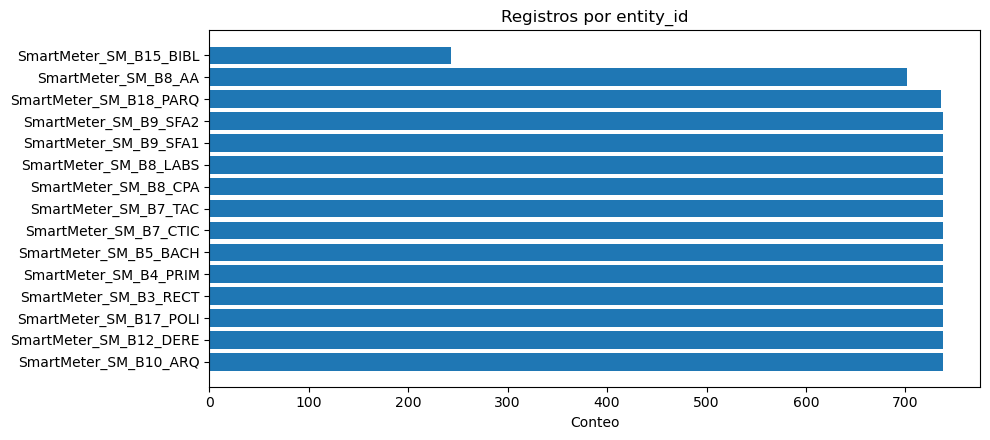

In [4]:
by_entity = data['entity_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(by_entity) * 0.3)))
ax.barh(by_entity.index.astype(str), by_entity.values)
ax.set_xlabel('Conteo')
ax.set_title('Registros por entity_id')
plt.tight_layout()
plt.show()

# 2. Conversión de tipos y drop de columnas

In [3]:
#Hacemos drop de columnas que no empleamos para cálculo de Indicadores o KPIs
data = data.drop(columns=["relativethdcurrent", "reactivepower", "reactiveenergyimport", "reactiveenergyexport"], errors='ignore')

In [4]:
#Convertimos tipos de datos
data["entity_id"] = data["entity_id"].astype("category")
data["time_index_colombia"] = pd.to_datetime(data["time_index_colombia"], errors="coerce")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10537 entries, 0 to 10536
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   entity_id            10537 non-null  category      
 1   time_index_colombia  10537 non-null  datetime64[ns]
 2   activepower          10537 non-null  float64       
 3   totalpowerfactor     10537 non-null  float64       
 4   relativethdvoltage   10537 non-null  float64       
 5   v1                   10537 non-null  float64       
 6   v2                   10537 non-null  float64       
 7   v3                   10537 non-null  float64       
 8   activeenergyimport   10537 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(7)
memory usage: 669.6 KB


In [5]:
data.head()

,entity_id,time_index_colombia,activepower,totalpowerfactor,relativethdvoltage,v1,v2,v3,activeenergyimport
0,SmartMeter_SM_B10_ARQ,2026-02-10 00:00:00,5905.228000,0.85760,1.588800,124.70360,125.718400,126.029200,2.654879e+07
1,SmartMeter_SM_B10_ARQ,2026-02-10 01:00:00,5745.960000,0.87880,1.409360,123.80520,125.075200,125.324000,2.655443e+07
2,SmartMeter_SM_B10_ARQ,2026-02-10 02:00:00,5663.420833,0.89375,1.449125,124.02875,125.420833,125.369167,2.655992e+07
3,SmartMeter_SM_B10_ARQ,2026-02-10 03:00:00,5873.392000,0.89280,1.553520,124.14520,125.348400,125.336400,2.656572e+07
4,SmartMeter_SM_B10_ARQ,2026-02-10 04:00:00,6610.020000,0.90480,1.468080,123.74720,124.499200,124.884000,2.657182e+07


# 3. Descripción estadística

#3.1 Generación de estadísticas descriptivas

In [6]:
data.describe()

,time_index_colombia,activepower,totalpowerfactor,relativethdvoltage,v1,v2,v3,activeenergyimport
count,10537,10537.000000,10537.000000,10537.000000,10537.000000,10537.000000,10537.000000,1.053700e+04
mean,2026-02-25 14:13:44.409224448,19009.322501,0.892775,1.774752,125.934549,126.108908,126.151210,5.219052e+07
min,2026-02-10 00:00:00,38.144000,-0.735833,0.744680,119.575948,120.571293,120.469200,2.028302e+04
25%,2026-02-17 20:00:00,5796.416667,0.885200,1.416126,123.797203,124.036667,124.110400,1.763658e+07
50%,2026-02-25 18:00:00,13404.218487,0.960769,1.689960,125.580000,125.850000,125.762800,5.077103e+07
75%,2026-03-05 09:00:00,29555.854237,0.983750,2.044400,127.478000,127.815000,127.641667,8.382903e+07
max,2026-03-12 17:00:00,83828.848000,0.990800,4.085395,133.520000,133.300000,133.530000,9.999255e+07
std,NaN,17548.483405,0.179653,0.487415,2.894508,2.676542,2.787572,3.220003e+07


#3.2 Histogramas y boxplots para las variables clave

<Axes: title={'center': 'Registros por día — cobertura temporal Medidores Landis'}, xlabel='Fecha', ylabel='N° registros'>

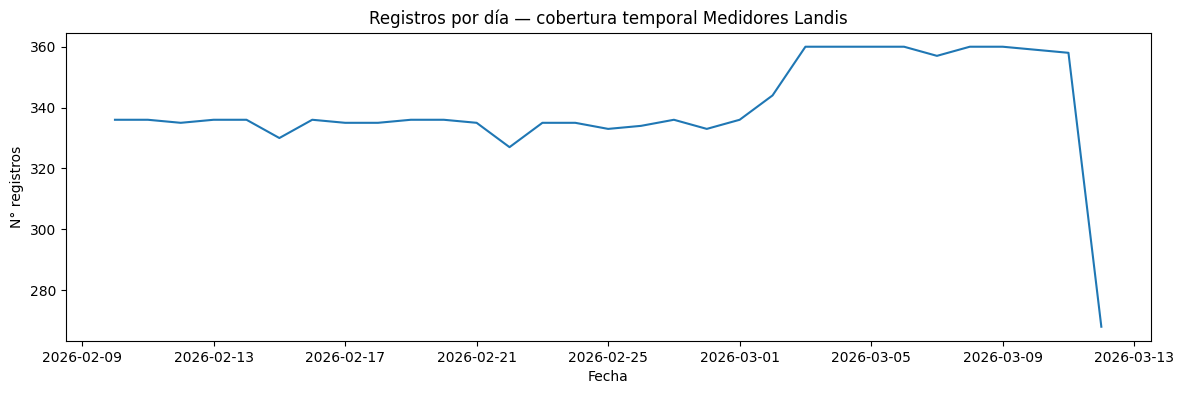

In [7]:
# Paso 2: visualización útil — registros por día
registros_por_dia = (
    data
    .groupby(data["time_index_colombia"].dt.date)
    .size()
    .rename("n_registros")
)

registros_por_dia.plot(
    kind="line",
    figsize=(14, 4),
    title="Registros por día — cobertura temporal Medidores Landis",
    xlabel="Fecha",
    ylabel="N° registros"
)


<Axes: title={'center': 'Registros por hora del día'}, xlabel='Hora', ylabel='N° registros'>

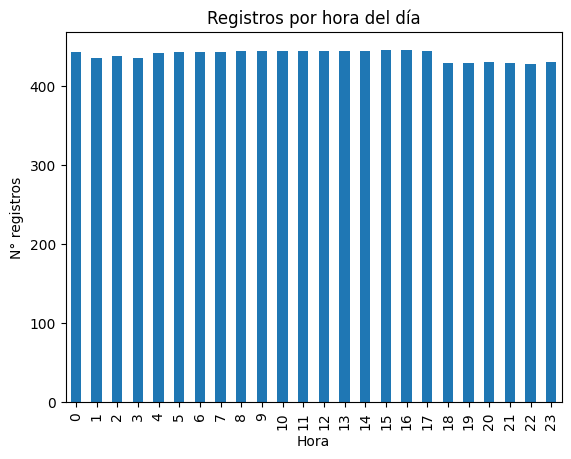

In [8]:
data["time_index_colombia"].dt.hour.value_counts().sort_index().plot(
    kind="bar",
    title="Registros por hora del día",
    xlabel="Hora",
    ylabel="N° registros"
)

<Axes: title={'center': 'Histograma - entity_id'}, xlabel='entity_id'>

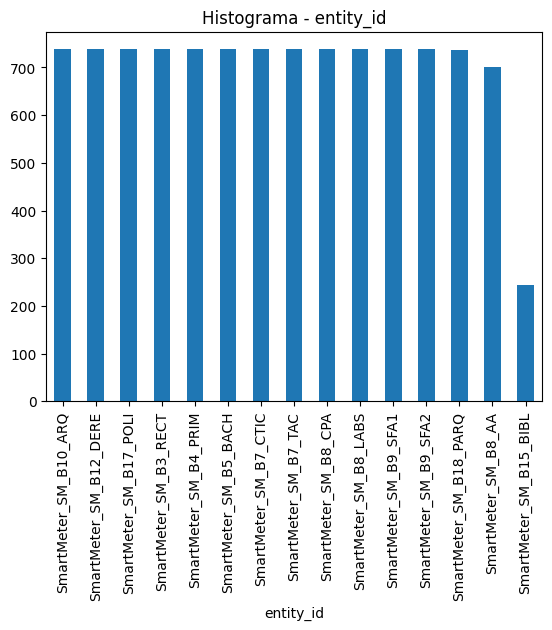

In [9]:
data['entity_id'].value_counts().plot(kind='bar', title="Histograma - entity_id")

<Axes: title={'center': 'Histograma - activepower'}, ylabel='Frequency'>

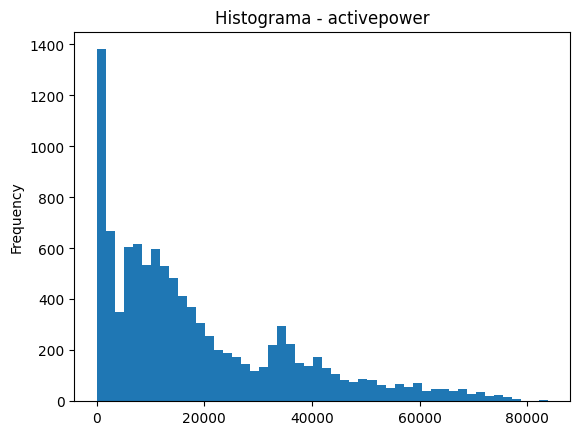

In [10]:
data['activepower'].plot(kind='hist', bins=50, title="Histograma - activepower")


<Axes: >

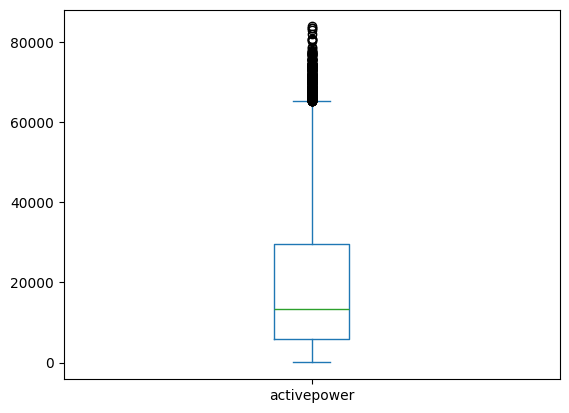

In [11]:
data['activepower'].plot(kind='box')

<Axes: title={'center': 'Histograma - activeenergyimport'}, ylabel='Frequency'>

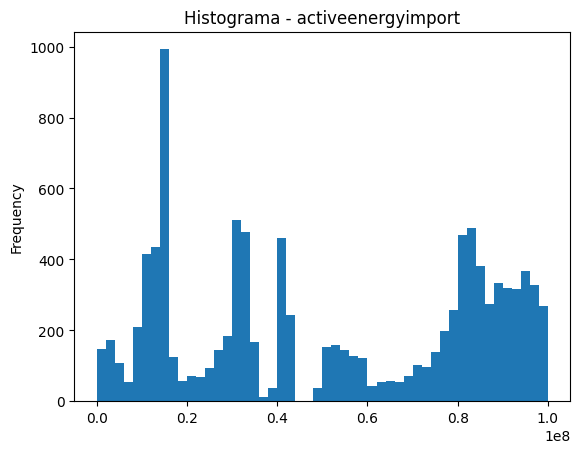

In [12]:
data['activeenergyimport'].plot(kind='hist', bins=50, title="Histograma - activeenergyimport")

<Axes: >

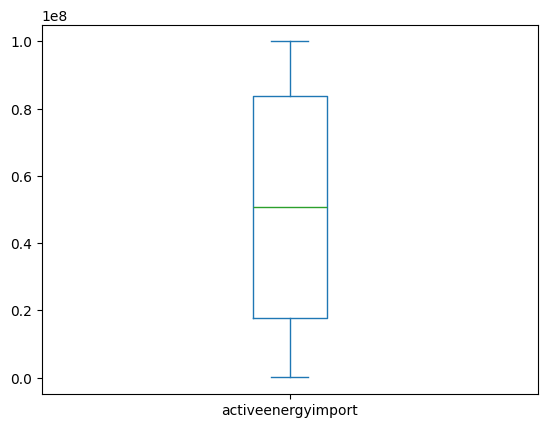

In [13]:
data['activeenergyimport'].plot(kind='box')

<Axes: title={'center': 'Histograma - relativethdvoltage'}, ylabel='Frequency'>

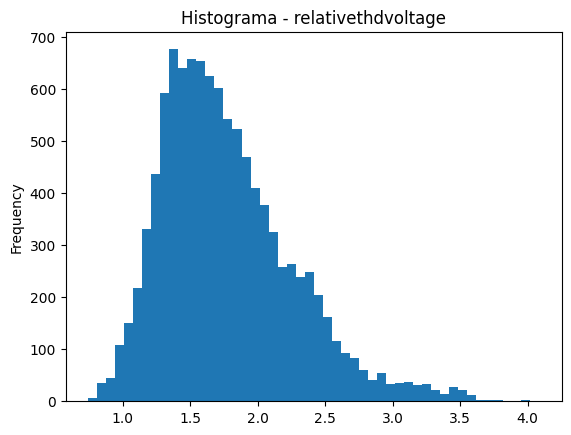

In [14]:
data['relativethdvoltage'].plot(kind='hist', bins=50, title="Histograma - relativethdvoltage")

<Axes: >

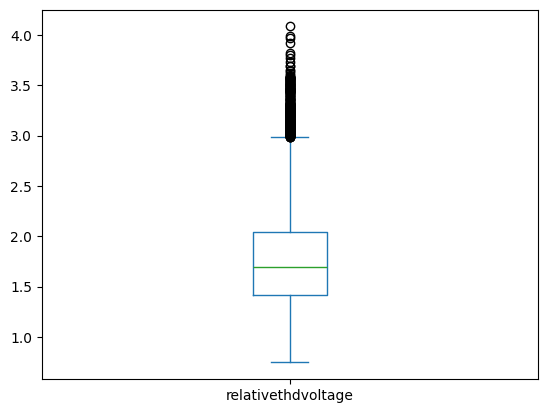

In [15]:
data['relativethdvoltage'].plot(kind='box')

<Axes: title={'center': 'Histograma - totalpowerfactor'}, ylabel='Frequency'>

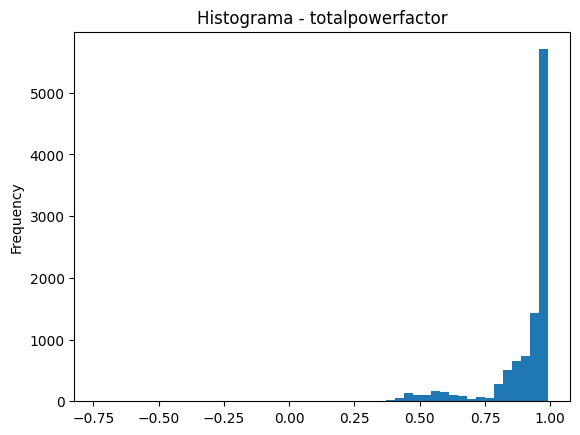

In [16]:
data['totalpowerfactor'].plot(kind='hist', bins=50, title="Histograma - totalpowerfactor")


<Axes: >

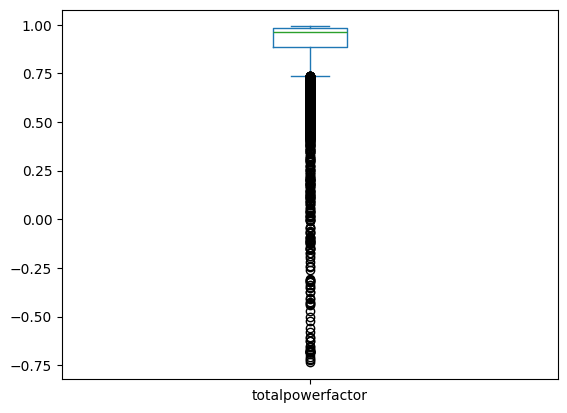

In [17]:
data['totalpowerfactor'].plot(kind='box')

<Axes: title={'center': 'Histograma - v1'}, ylabel='Frequency'>

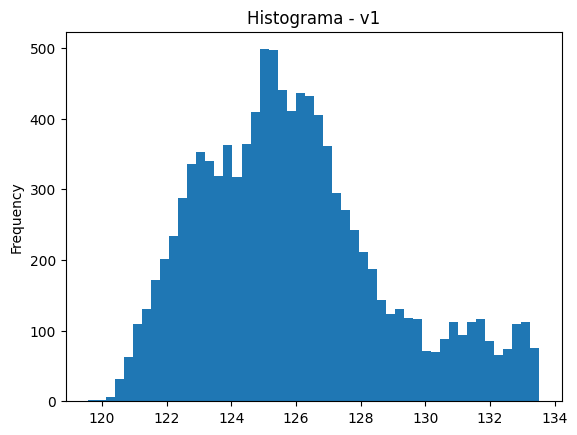

In [18]:
data['v1'].plot(kind='hist', bins=50, title="Histograma - v1")

<Axes: >

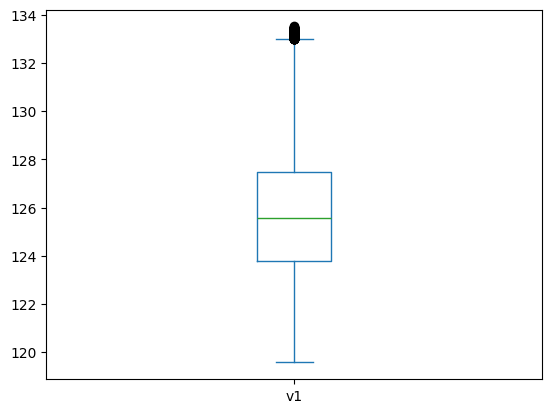

In [19]:
data['v1'].plot(kind='box')

<Axes: title={'center': 'Histograma - v2'}, ylabel='Frequency'>

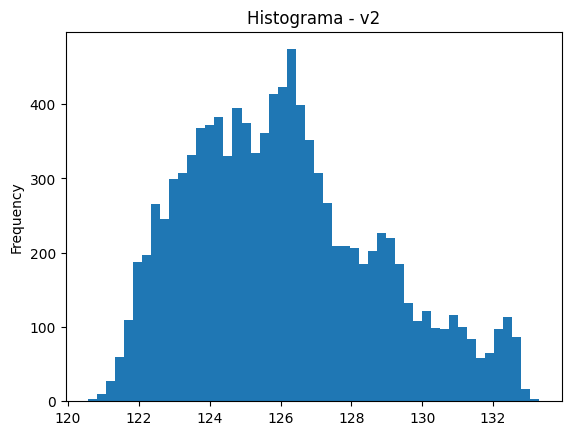

In [20]:
data['v2'].plot(kind='hist', bins=50, title="Histograma - v2")

<Axes: >

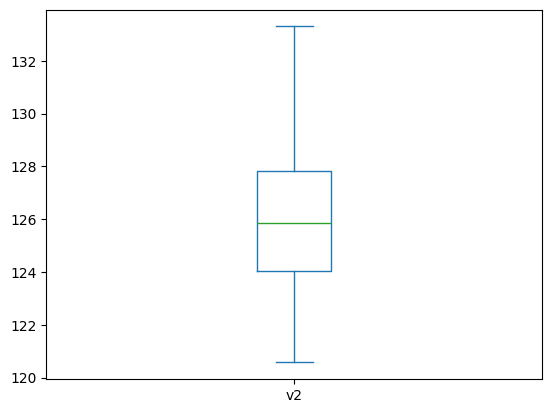

In [21]:
data['v2'].plot(kind='box')

<Axes: title={'center': 'Histograma - v3'}, ylabel='Frequency'>

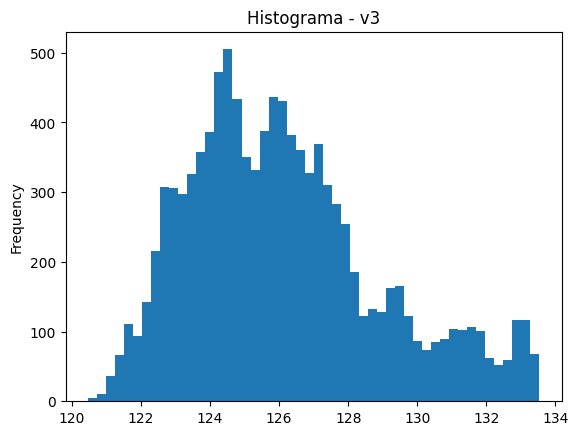

In [22]:
data['v3'].plot(kind='hist', bins=50, title="Histograma - v3")

<Axes: >

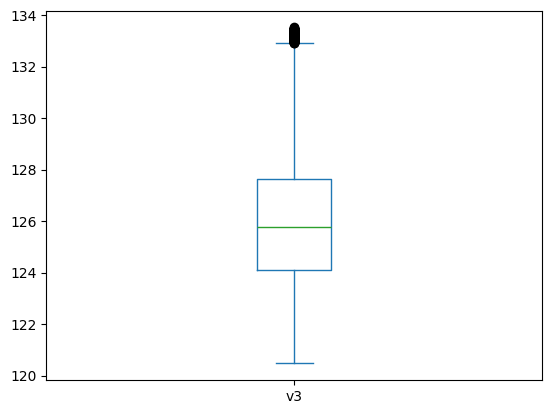

In [23]:
data['v3'].plot(kind='box')

Anotación: No se aplica eliminación de valores atípicos, ya que estos pueden representar condiciones operativas reales críticas para los indicadores energéticos y KPIs.

# 4. Limpieza de nulos

In [24]:
# 4.1 Convertir columnas numéricas
for col in ["activepower", "totalpowerfactor", "activeenergyimport"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# 4.2 Validación de rangos físicos. Los valores fuera de rango se declaran como NaN
RANGOS = {
    "activeenergyimport":   (0,       500_000_000),
    "relativethdvoltage":   (0,       100),
    "totalpowerfactor":     (-1.0,    1.0),
    "activepower":          (0,       2_000_000),
    "relativethdcurrent":   (0,       200),
    "v1":                   (114.45,  133.53),
    "v2":                   (114.45,  133.53),
    "v3":                   (114.45,  133.53),
}

for col, (vmin, vmax) in RANGOS.items():
    if col not in data.columns:
        continue
    fuera = ~data[col].between(vmin, vmax, inclusive="both") & data[col].notna()
    n_fuera = fuera.sum()
    if n_fuera > 0:
        print(f"  {col}: {n_fuera} fuera de rango → NaN")
        data.loc[fuera, col] = np.nan

# 4.3 Eliminar filas sin información esencial
data = data.dropna(subset=["time_index_colombia", "entity_id", "activepower"])

data = data.reset_index(drop=True)
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10537 entries, 0 to 10536
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   entity_id            10537 non-null  category      
 1   time_index_colombia  10537 non-null  datetime64[ns]
 2   activepower          10537 non-null  float64       
 3   totalpowerfactor     10537 non-null  float64       
 4   relativethdvoltage   10537 non-null  float64       
 5   v1                   10537 non-null  float64       
 6   v2                   10537 non-null  float64       
 7   v3                   10537 non-null  float64       
 8   activeenergyimport   10537 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(7)
memory usage: 669.6 KB


# 5. Guardar dataset limpio

In [25]:

#CLEAN_OUTPUT_PARQUET = "segunda_revision.parquet"
#CLEAN_OUTPUT_CSV     = "segunda_revision.csv"

# Guardar archivos
#data.to_parquet(CLEAN_OUTPUT_PARQUET, index=False)
#data.to_csv(CLEAN_OUTPUT_CSV, index=False)

#print("✔️ Archivos guardados:")
#print(f"- Dataset limpio (parquet): {CLEAN_OUTPUT_PARQUET}")
#print(f"- Dataset limpio (CSV):     {CLEAN_OUTPUT_CSV}")


Si hubiese cambios, este bloque no estaría comentado, pero el csv inicial ya tenía un proceso de calidad de datos excelente.

In [26]:
#Cargar dataset limpio para cálculo de indicadores
#data = pd.read_parquet("landis_clean.parquet")

#print("✔️ Dataset limpio cargado para cálculo de indicadores.")
#print(f"Total de registros: {len(data):,}")


# 6. Cálculo de indicadores

Indicadores calculados por medidor y día. La franja horaria de operación para f1 es 07:00-21:59.

La energía diaria se obtiene como: max(activeenergyimportday) - min(activeenergyimportday) del día.


## Indicadores calculados:

**Por medidor y dia:**
- LF = promedio / maximo de potencia (curva completa del dia)
- PAR = maximo / promedio de potencia
- f1 = promedio franja diurna (07:00-21:59) / maximo del dia
- f2_CV = desviacion estandar / promedio franja diurna (coeficiente de variacion)
- f3 = minimo / promedio franja diurna
- f4 = potencia promedio nocturna (22:00-06:59) / potencia promedio diaria
- desbalance_pct = desbalance de tension entre fases v1, v2, v3

**Agregados por medidor y dia:**
- HU_horas = energia del dia (kWh) / potencia maxima (kW)
- CO2_tCO2e = 9.7018e-8 x energia del dia (Wh)
- Ahorro de energia: excluido (requiere baseline institucional definida)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cálculo de indicadores por medidor y día
# Dataset requerido: data con columnas [entity_id, fecha, hora, activepower,
#                    activeenergyimport, v1, v2, v3, totalpowerfactor,
#                    relativethdvoltage]
# Indicadores excluidos por falta de fuente de datos en este dataset:
#   - IGS (requiere Fronius/Enphase: energyproducedtoday, P_instalada)
#   - TCP (requiere Fronius: paneltemperature, ambienttemperature)
#   - EB  (requiere etinverterxw: energyfrombattery, energytobattery)
#   - Ahorro (requiere línea base institucional definida)
# ─────────────────────────────────────────────────────────────────────────────

##Fecha y hora
data["fecha"] = data["time_index_colombia"].dt.date
data["hora"]  = data["time_index_colombia"].dt.hour

# Parámetros de franjas horarias
HORA_OPERACIONAL_INI  = 6   # 06:00
HORA_OPERACIONAL_FIN  = 21  # hasta 21:59 inclusive
HORA_NO_OPERACIONAL_INI   = 22  # 22:00–23:59
HORA_NO_OPERACIONAL_FIN   = 5   # 00:00–05:59

# Factor de emisión XM S.A. E.S.P., preliminar 2025
FACTOR_CO2_TCO2_POR_WH = 9.7018e-8  # tCO2e / Wh

# ── Máscaras de franja ────────────────────────────────────────────────────────

def mask_operacional(df):
    return df["hora"].between(HORA_OPERACIONAL_INI, HORA_OPERACIONAL_FIN)

def mask_no_operacional(df):
    return (df["hora"] >= HORA_NO_OPERACIONAL_INI) | (df["hora"] <= HORA_NO_OPERACIONAL_FIN)

# ── Energía diaria por medidor ────────────────────────────────────────────────

energia_dia = (
    data.groupby(["entity_id", "fecha"])["activeenergyimport"]
    .agg(lambda x: x.max() - x.min())
    .rename("energia_dia_wh")
    .reset_index()
)

# ── Función principal: indicadores por grupo (entity_id + fecha) ──────────────

def calcular_indicadores(df):
    ap       = df["activepower"].dropna()
    ap_operacional  = df.loc[mask_operacional(df), "activepower"].dropna()
    ap_no_operacional = df.loc[mask_no_operacional(df), "activepower"].dropna()

    # Energía del día (Wh)
    e_dia_wh = df["activeenergyimport"].max() - df["activeenergyimport"].min()

    # LF y PAR — curva completa del día
    lf  = ap.mean() / ap.max()           if ap.max()  > 0 else np.nan
    par = ap.max()  / ap.mean()          if ap.mean() > 0 else np.nan

    # f1 — uniformidad franja diurna (06:00–21:59)
    f1  = ap_operacional.mean() / ap_operacional.max() if ap_operacional.max()  > 0 else np.nan

    # f2 — coeficiente de variación franja diurna
    f2  = ap_operacional.std()  / ap_operacional.mean() if ap_operacional.mean() > 0 else np.nan

    # f3 — relación mínimo–promedio franja diurna
    f3  = ap_operacional.min()  / ap_operacional.mean() if ap_operacional.mean() > 0 else np.nan

    # f4 — factor de carga nocturna
    f4  = ap_no_operacional.mean() / ap_operacional.mean()    if ap_operacional.mean() > 0 else np.nan

    # HU — horas de utilización  (Wh / W = h, sin constante de conversión)
    hu  = e_dia_wh / ap.max()  if ap.max()  > 0 else np.nan

    # Emisiones CO2
    co2 = FACTOR_CO2_TCO2_POR_WH * e_dia_wh

    # Desbalance de tensión (%)
    v_bar = (df["v1"] + df["v2"] + df["v3"]) / 3
    desv  = (
        df[["v1", "v2", "v3"]].subtract(v_bar, axis=0).abs().max(axis=1) / v_bar
    ) * 100
    desbalance = desv.mean()

    # Factor de potencia promedio
    fp = df["totalpowerfactor"].mean()

    # THD-V promedio
    thd_v = df["relativethdvoltage"].mean()

    return pd.Series({
        "LF":         lf,
        "PAR":        par,
        "f1":         f1,
        "f2_CV":      f2,
        "f3":         f3,
        "f4":         f4,
        "HU_horas":   hu,
        "CO2_tCO2e":  co2,
        "desbalance_pct": desbalance,
        "fp_promedio":    fp,
        "thd_v_pct":      thd_v,
    })

# ── Calcular y almacenar ──────────────────────────────────────────────────────

indicadores_diarios = (
    data
    .groupby(["entity_id", "fecha"])
    .apply(calcular_indicadores)
    .reset_index()
)

print(f"Indicadores calculados: {len(indicadores_diarios):,} registros "
      f"({indicadores_diarios['entity_id'].nunique()} medidores)")
indicadores_diarios.head()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\4136331096.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indicadores_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\4136331096.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indicadores_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\4136331096.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

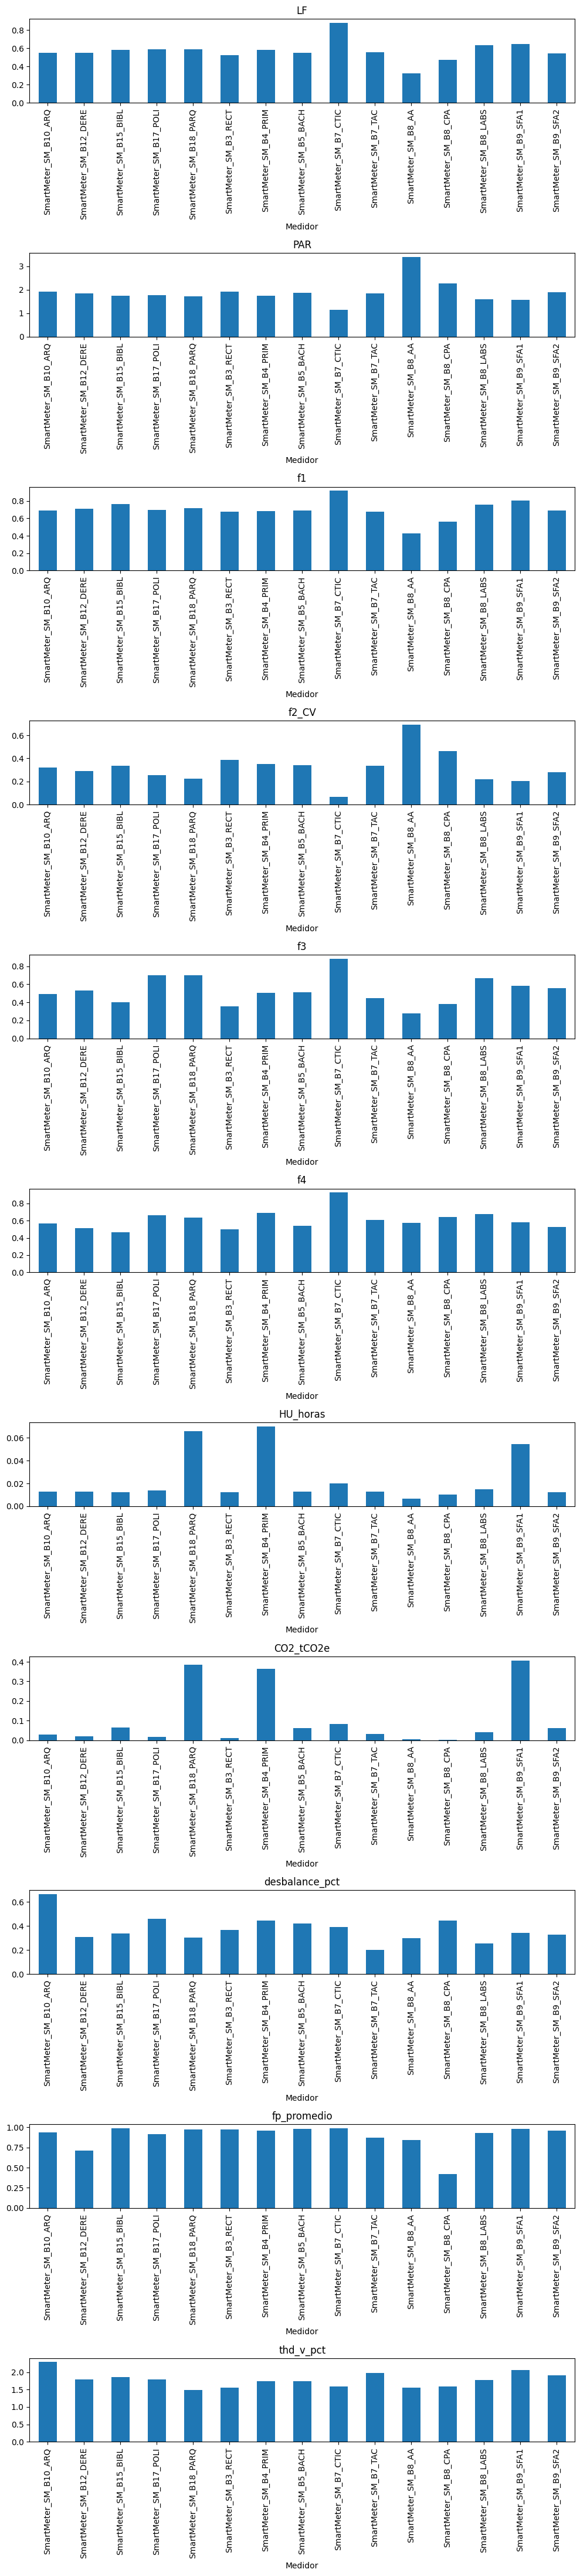

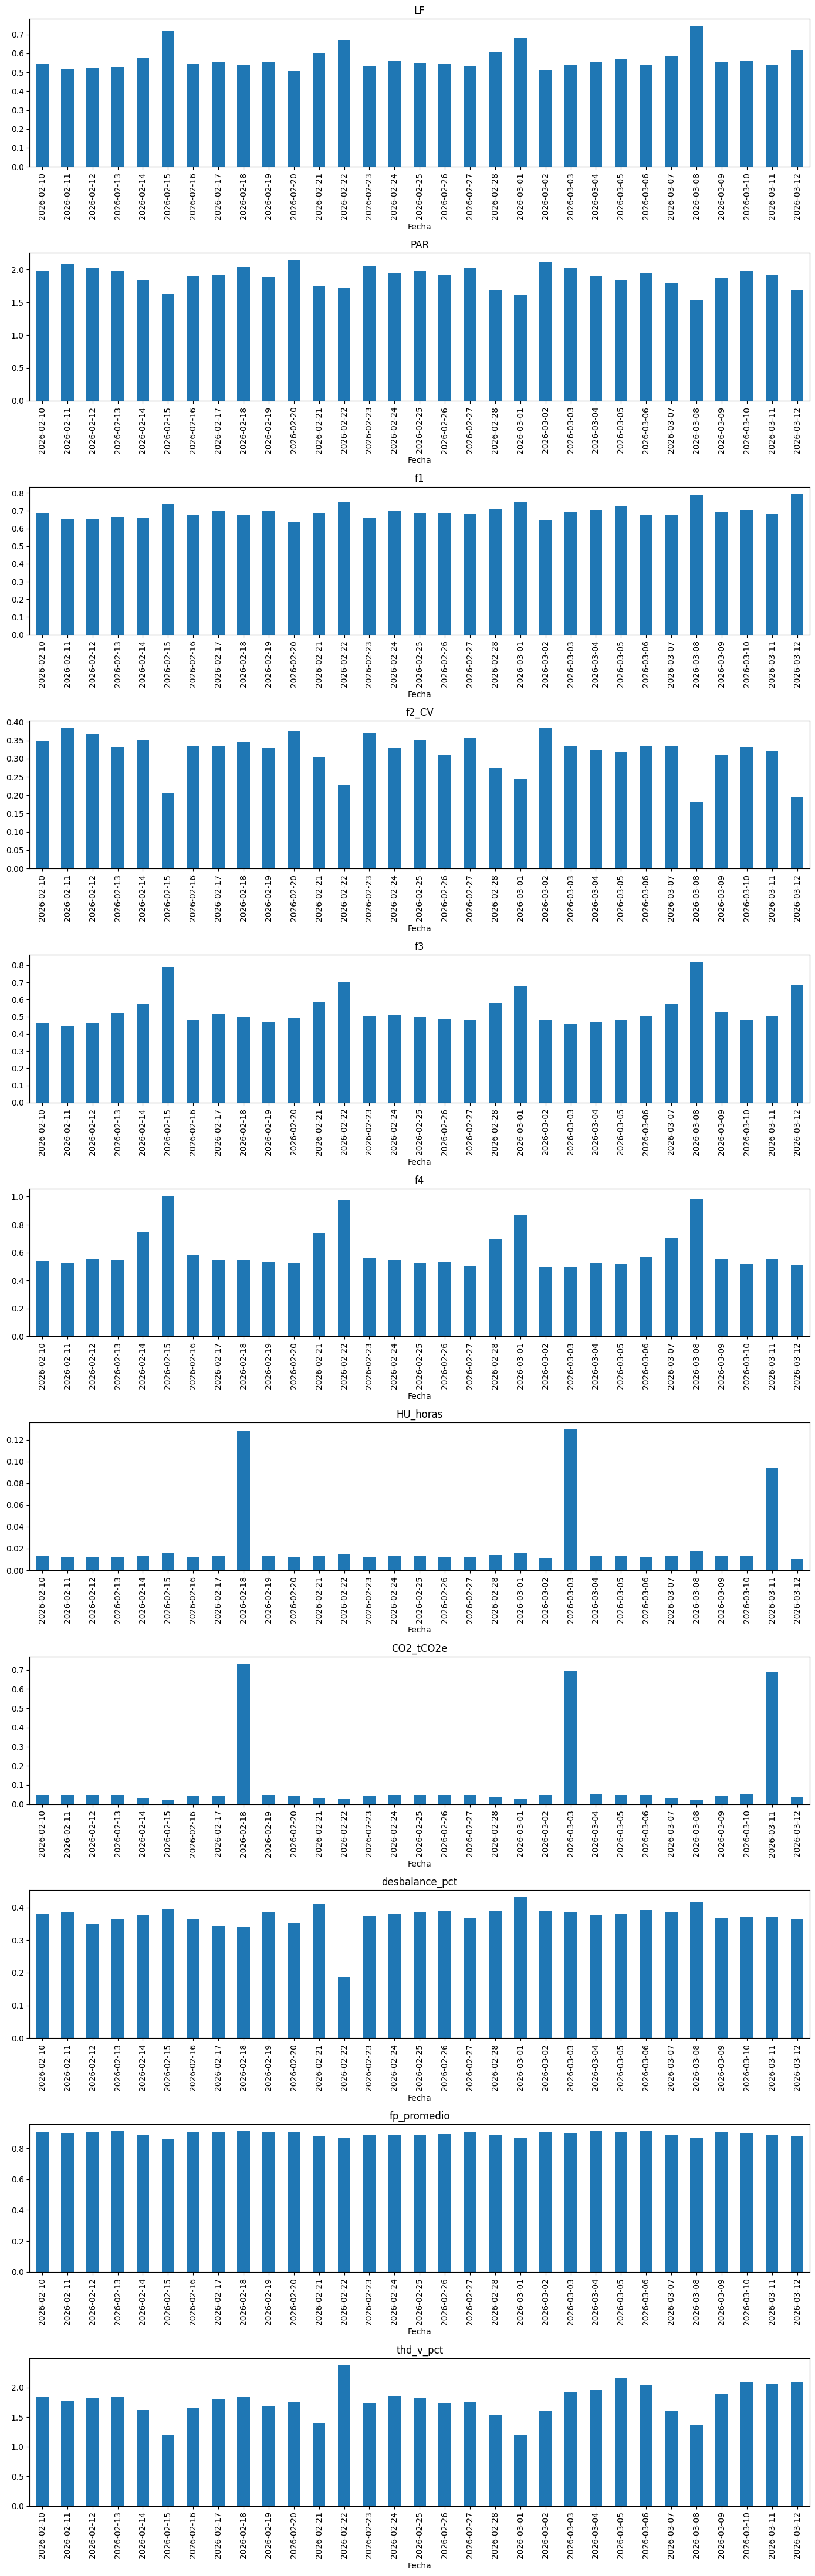

In [28]:
cols_indicadores = [
    "LF", "PAR", "f1", "f2_CV", "f3", "f4",
    "HU_horas", "CO2_tCO2e", "desbalance_pct", "fp_promedio", "thd_v_pct"
]

# Por medidor
fig, axes = plt.subplots(len(cols_indicadores), 1, figsize=(10, 4 * len(cols_indicadores)))
for ax, col in zip(axes, cols_indicadores):
    indicadores_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Medidor")
plt.tight_layout()
plt.show()

# Por día
fig, axes = plt.subplots(len(cols_indicadores), 1, figsize=(14, 4 * len(cols_indicadores)))
for ax, col in zip(axes, cols_indicadores):
    indicadores_diarios.groupby("fecha")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cálculo de KPIs por medidor y día
# KPIs excluidos por dependencias no resueltas:
#   - KPI 01 (consumo/m²): requiere área por bloque — pendiente Planeación Física
#   - KPI 02 (intensidad/usuario): requiere N_usuarios — pendiente institucional
#   - KPI 04 (ahorro verificado): requiere línea base del año anterior
#   - KPI 06 (PR): requiere Fronius solarirradiation — fuente no integrada
#   - KPI 07 (SS): requiere energyproducedtoday — fuente no integrada
# ─────────────────────────────────────────────────────────────────────────────

FE_2025 = 0.000097018   # tCO2e/kWh — XM S.A. E.S.P., preliminar 2025
UMBRAL_F4       = 0.20  # alerta si f4 > 20%
UMBRAL_FP       = 0.9   # alerta si FP < 0.9
UMBRAL_THD      = 5.0   # alerta si THD-V >= 5%

def calcular_kpis(df):
    ap    = df["activepower"].dropna()
    e_dia_wh = df["activeenergyimport"].max() - df["activeenergyimport"].min()
    e_dia_kwh = e_dia_wh / 1000

    ap_noche = df.loc[(df["hora"] >= 22) | (df["hora"] <= 6), "activepower"].dropna()

    # KPI 03 — Pico de demanda
    idx_pico  = ap.idxmax()
    kpi03_kw  = ap.max()
    kpi03_hora = df.loc[idx_pico, "hora"] if idx_pico in df.index else np.nan

    # KPI 05 — Emisiones CO2
    kpi05_co2 = FE_2025 * e_dia_kwh

    # KPI 08 — Load Factor
    kpi08_lf  = ap.mean() / ap.max() if ap.max() > 0 else np.nan

    # KPI 09 — Consumo nocturno f4 (fracción de energía, no ratio de potencias)
    e_noche_wh = (
        df.loc[(df["hora"] >= 22) | (df["hora"] <= 6), "activepower"].sum()
    )  # proxy: suma de potencia horaria ∝ energía con Δt=1h
    e_total_proxy = ap.sum()
    kpi09_f4 = (e_noche_wh / e_total_proxy * 100) if e_total_proxy > 0 else np.nan

    # KPI 10 — Desbalance de tensión
    v_bar = (df["v1"] + df["v2"] + df["v3"]) / 3
    db = (df[["v1","v2","v3"]].subtract(v_bar, axis=0).abs().max(axis=1) / v_bar * 100)
    kpi10_db = db.mean()

    # KPI 11 — Factor de potencia
    kpi11_fp  = df["totalpowerfactor"].mean()

    # KPI 12 — THD-V
    kpi12_thd = df["relativethdvoltage"].mean()

    return pd.Series({
        "KPI03_pico_kw":      kpi03_kw,
        "KPI03_hora_pico":    kpi03_hora,
        "KPI05_CO2_tCO2e":    kpi05_co2,
        "KPI08_LF":           kpi08_lf,
        "KPI09_f4_pct":       kpi09_f4,
        "KPI10_desbalance_pct": kpi10_db,
        "KPI11_fp":           kpi11_fp,
        "KPI12_thd_v_pct":    kpi12_thd,
    })

kpis_diarios = (
    data
    .groupby(["entity_id", "fecha"])
    .apply(calcular_kpis)
    .reset_index()
)

print(f"KPIs calculados: {len(kpis_diarios):,} registros "
      f"({kpis_diarios['entity_id'].nunique()} medidores)")
kpis_diarios.head()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\2993829377.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kpis_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\2993829377.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kpis_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\2993829377.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

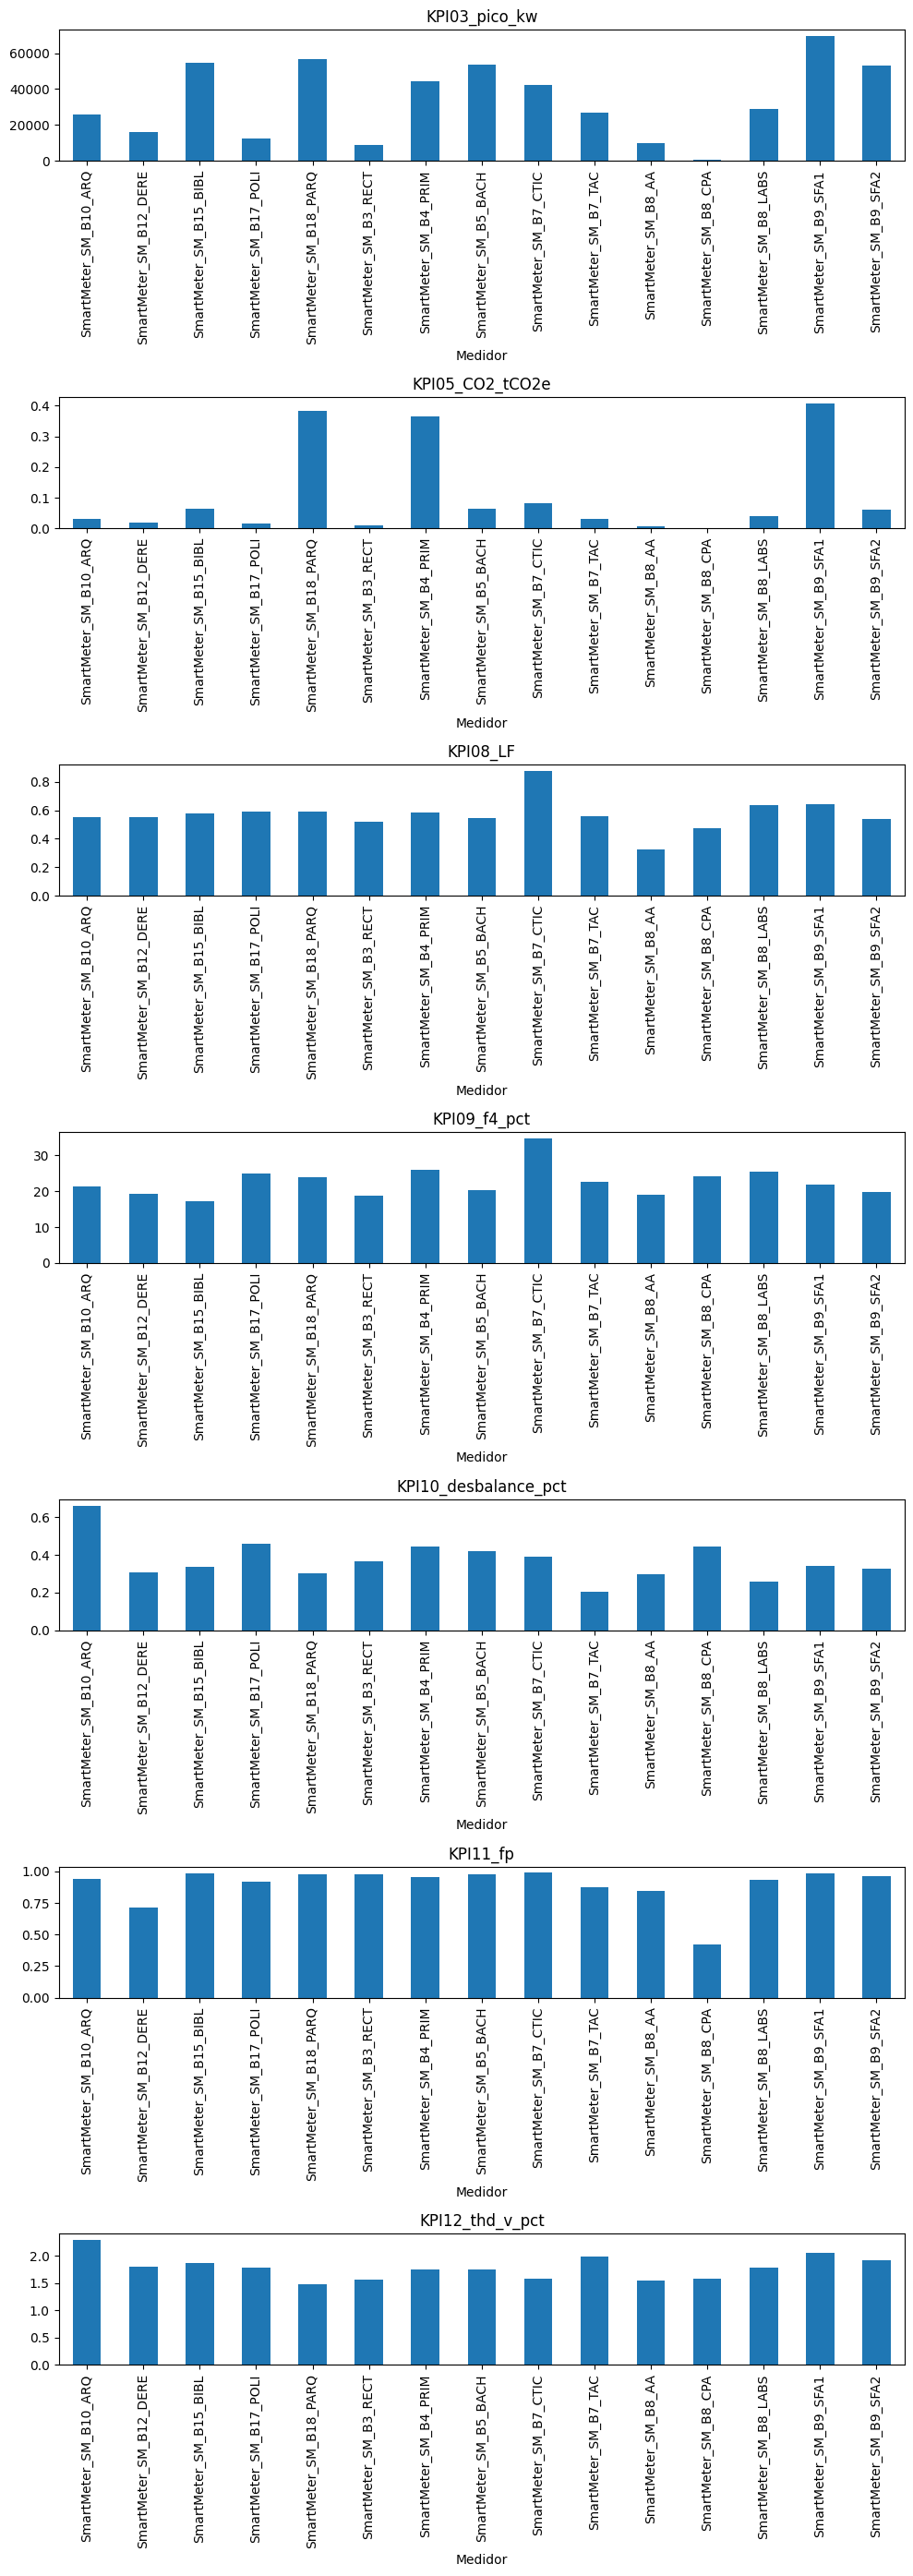

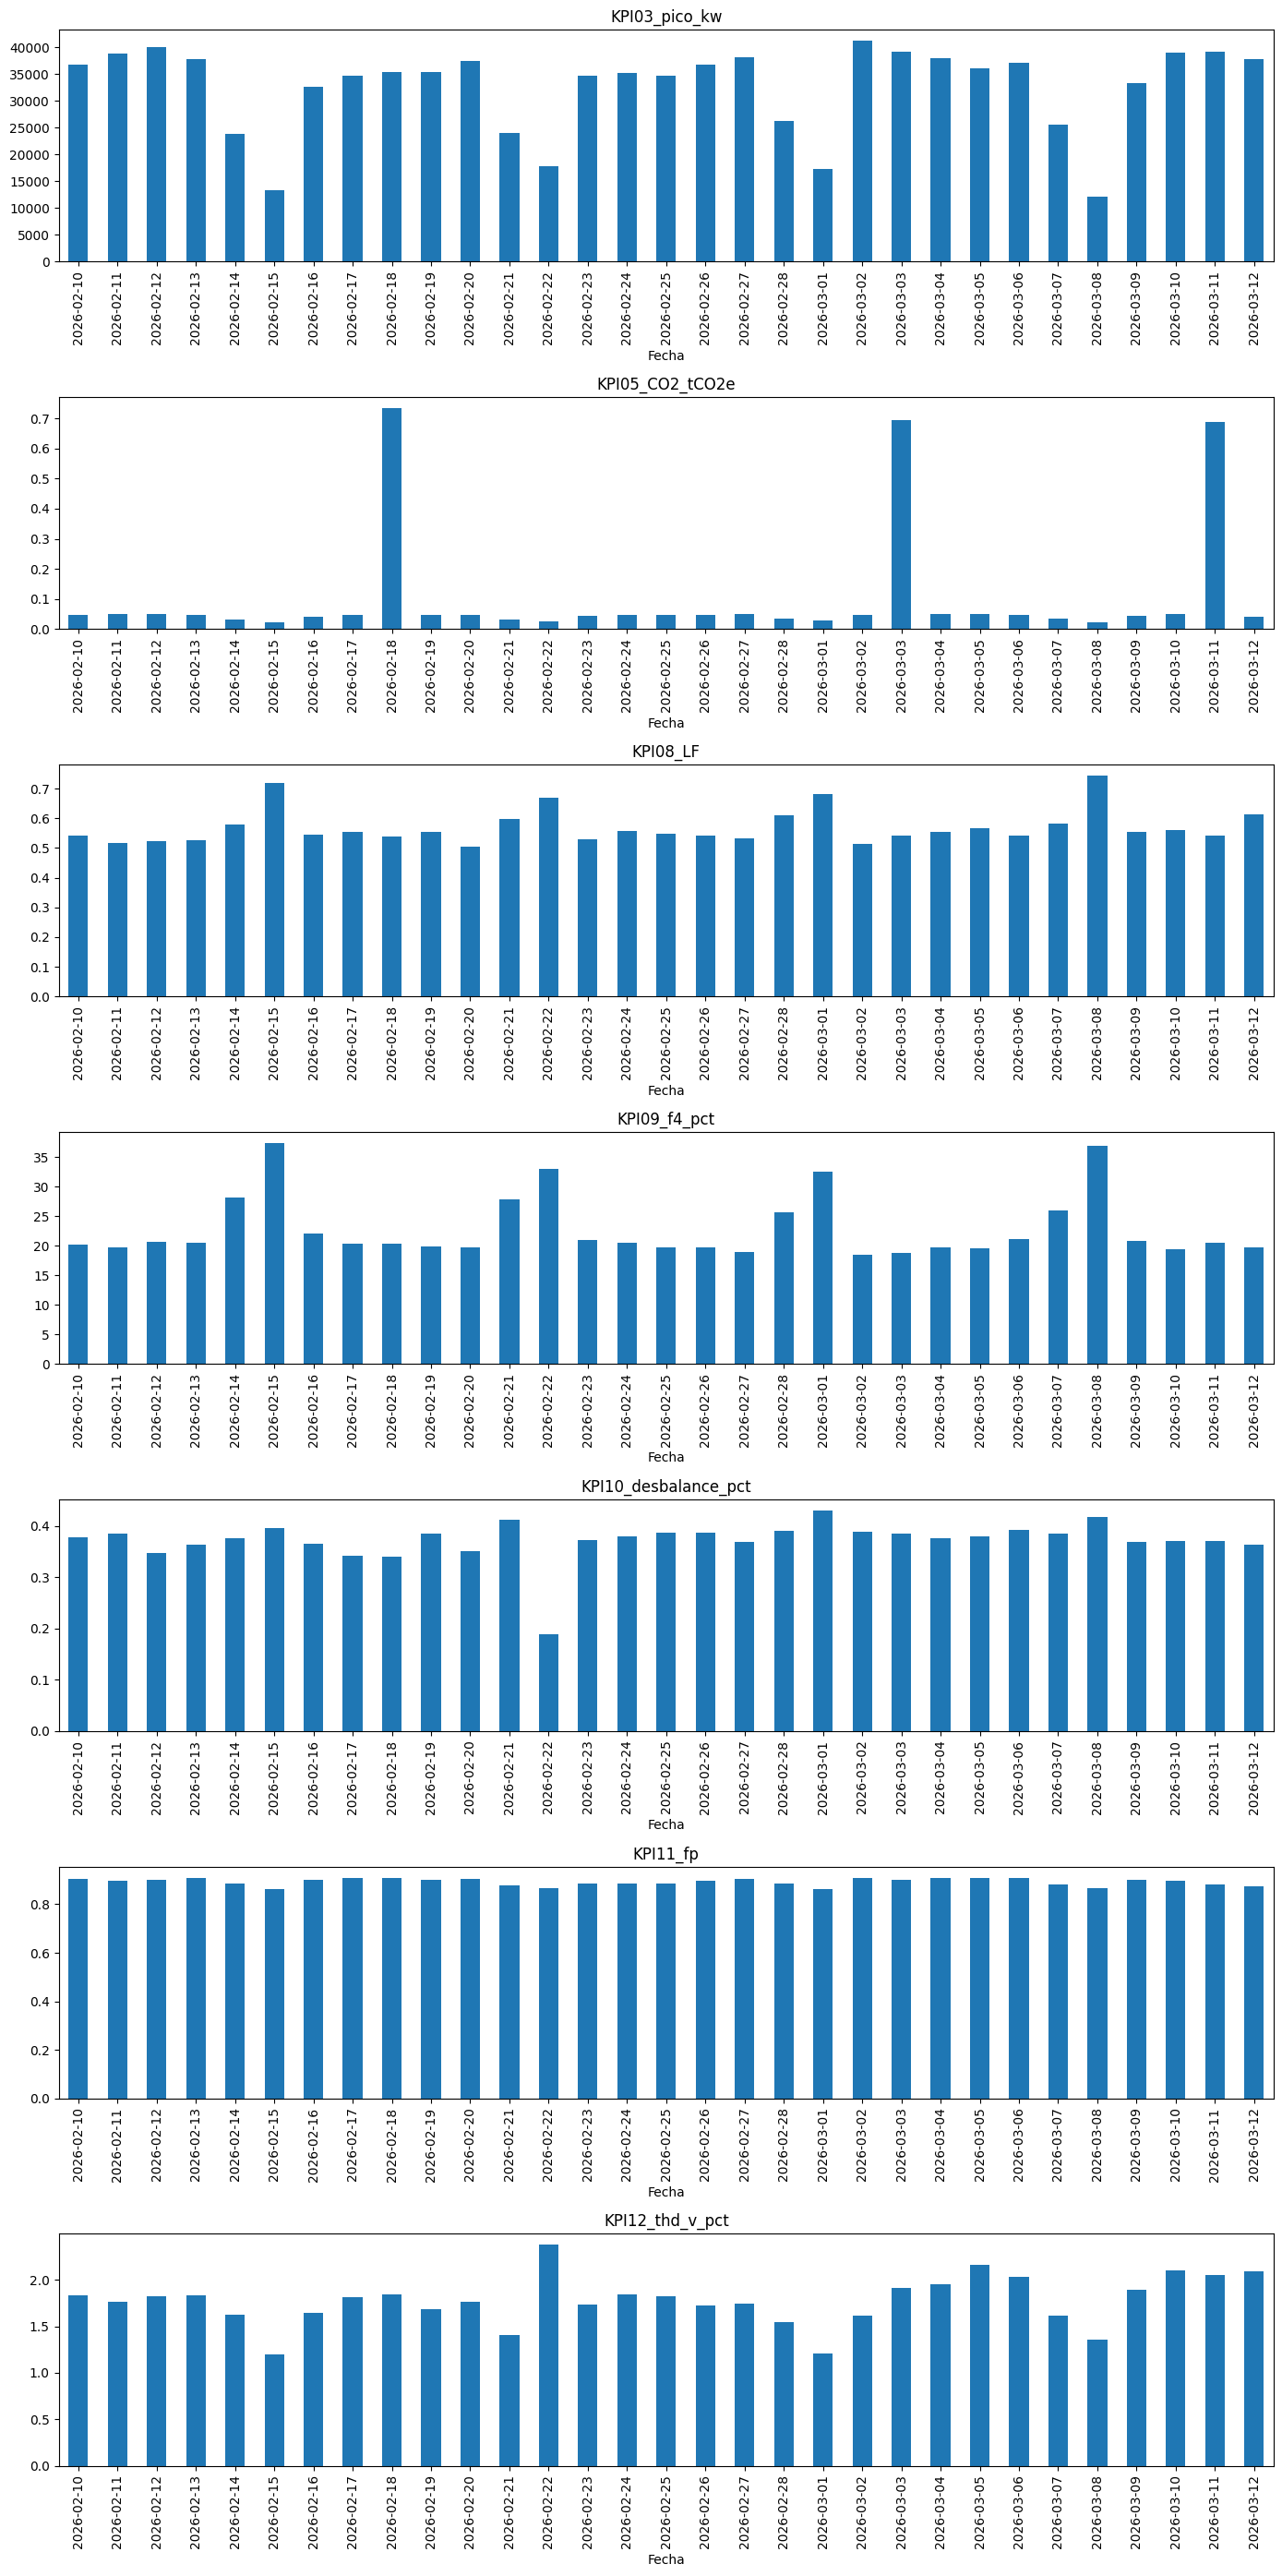

In [30]:
cols_kpis = [
    "KPI03_pico_kw", "KPI05_CO2_tCO2e", "KPI08_LF",
    "KPI09_f4_pct", "KPI10_desbalance_pct", "KPI11_fp", "KPI12_thd_v_pct"
]

# Por medidor
fig, axes = plt.subplots(len(cols_kpis), 1, figsize=(10, 4 * len(cols_kpis)))
for ax, col in zip(axes, cols_kpis):
    kpis_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Medidor")
plt.tight_layout()
plt.show()

# Por día
fig, axes = plt.subplots(len(cols_kpis), 1, figsize=(14, 4 * len(cols_kpis)))
for ax, col in zip(axes, cols_kpis):
    kpis_diarios.groupby("fecha")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

#PENDIENTE DE EDITAR

In [31]:
# 6.5. Exportar resultados

# Indicadores por medidor
#indicadores_por_medidor.to_csv(
 #   "indicadores_por_medidor.csv",
  #  index=False,
   # encoding="utf-8-sig"
#)

#indicadores_por_medidor.to_excel(
 #   "indicadores_por_medidor.xlsx",
  #  index=False
#)

# Indicadores diarios
indicadores_diarios.to_csv(
    "indicadores_diarios.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_diarios.to_excel(
    "indicadores_diarios.xlsx",
    index=False
)

# kpis diarios
kpis_diarios.to_csv(
    "kpis_diarios.csv",
    index=False,
    encoding="utf-8-sig"
)

kpis_diarios.to_excel(
    "kpis_diarios.xlsx",
    index=False
)

print("Faltan indicadores y kpis por medidor")

print("✔️ Resultados exportados:")

print(" - indicadores_diarios.csv")
print(" - indicadores_diarios.xlsx")
print(" - kpis_diarios.csv")
print(" - kpis_diarios#.xlsx")


Faltan indicadores y kpis por medidor
✔️ Resultados exportados:
 - indicadores_diarios.csv
 - indicadores_diarios.xlsx
 - kpis_diarios.csv
 - kpis_diarios#.xlsx


In [32]:
# 6.6. Verificar rangos de indicadores

cols_indicadores = [
    "LF",
    "PAR",
    "f1",
    "f2_CV",
    "f3",
    "f4",
    "HU_horas",
    "CO2_tCO2e",
    "desbalance_pct",
]

indicadores_diarios[cols_indicadores].describe().T


,count,mean,std,min,25%,50%,75%,max
LF,445.0,0.570584,0.148015,0.210262,0.491355,0.549604,0.635208,0.951972
PAR,445.0,1.891548,0.604086,1.050451,1.574288,1.819490,2.035190,4.755980
f1,445.0,0.695430,0.137794,0.208214,0.624973,0.700832,0.786083,0.971408
f2_CV,445.0,0.316923,0.179742,0.017200,0.199207,0.296234,0.408527,1.066727
f3,445.0,0.539464,0.210600,0.042311,0.370934,0.532898,0.692358,0.976332
f4,445.0,0.613652,0.222196,0.155211,0.456163,0.564571,0.718307,2.303609
HU_horas,445.0,0.023406,0.126949,0.003126,0.011418,0.012806,0.014818,1.763003
CO2_tCO2e,445.0,0.107320,0.791328,0.000209,0.015379,0.035624,0.073408,9.699000
desbalance_pct,445.0,0.372549,0.121211,0.077474,0.305900,0.355815,0.438288,0.894102
